  SVM KERNEL COMPARISON — SYNTHETIC DATASETS

Kernel                  Moons Acc  Circles Acc
----------------------------------------------
Linear Kernel              0.8733       0.5267
Polynomial (d=2)           0.5067       0.9367
Polynomial (d=3)           0.8800       0.6467
RBF Kernel                 0.9400       0.9400


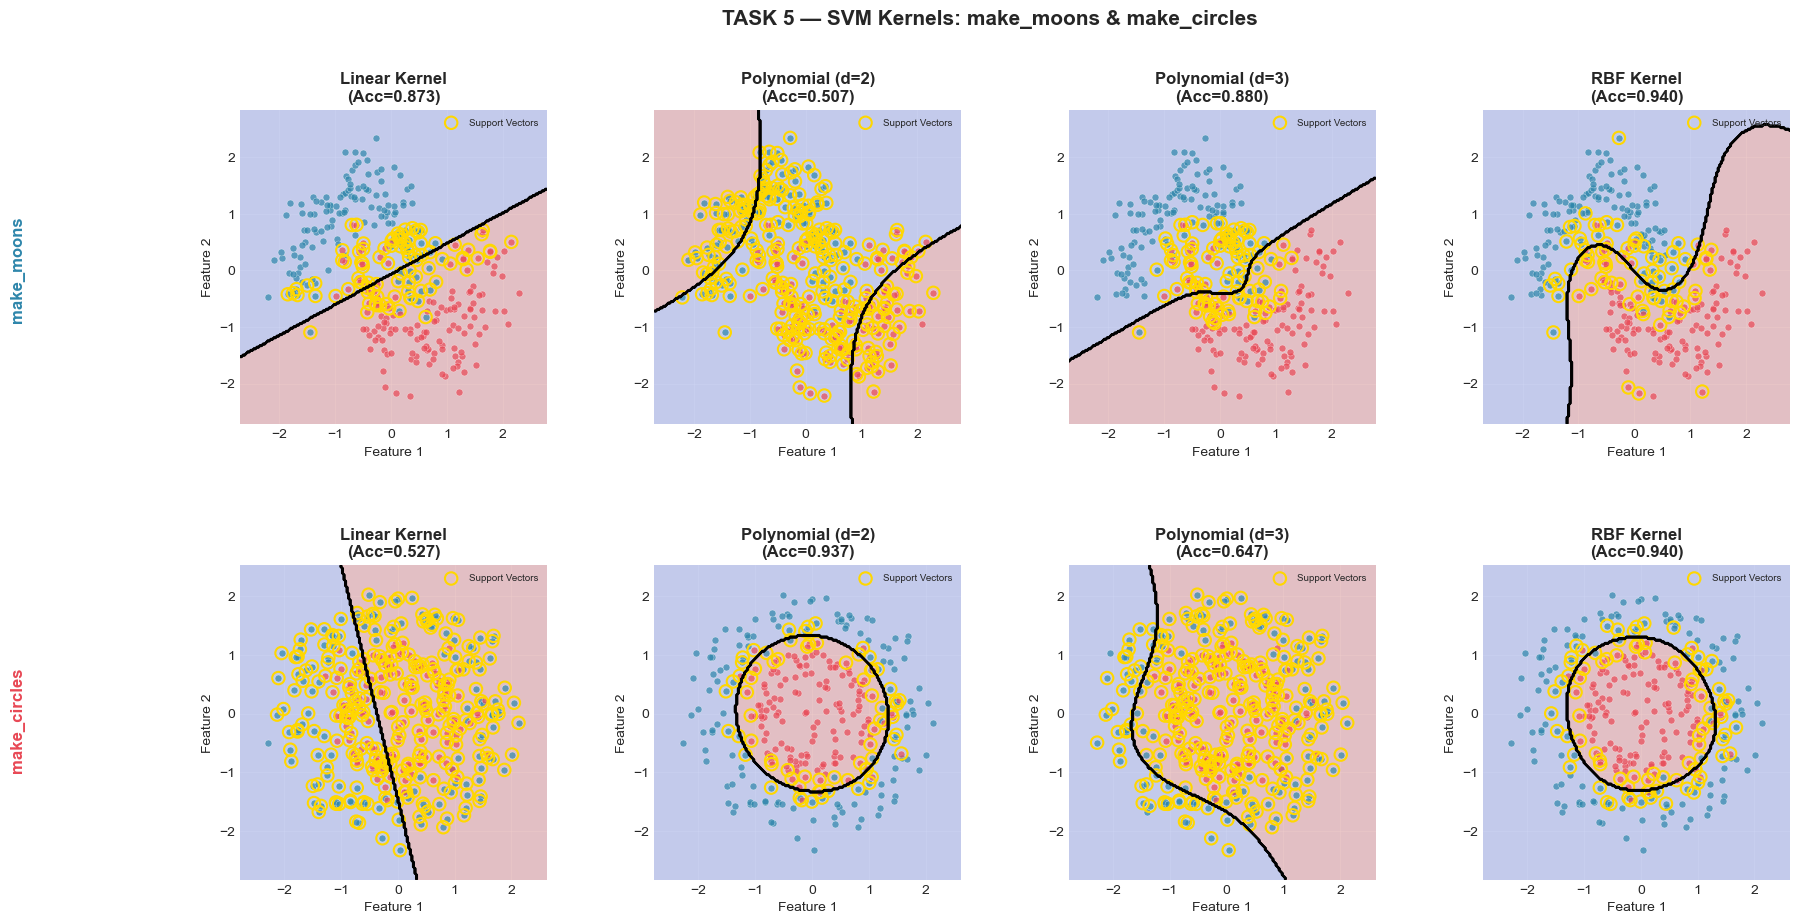


  BREAST CANCER — RBF SVM + GridSearchCV
Best C     : 10
Best gamma : 0.01
Best CV Acc: 0.9802

SVM Test Accuracy : 0.9825
SVM F1-Score      : 0.9825
SVM AUC-ROC       : 0.9980

  COMPARING ALL 5 CLASSIFIERS
Logistic Regression   : Acc=0.9825  F1=0.9825  AUC=0.9954
KNN (K=5)             : Acc=0.9649  F1=0.9647  AUC=0.9792
Random Forest         : Acc=0.9561  F1=0.9560  AUC=0.9937
SVM (RBF)             : Acc=0.9825  F1=0.9825  AUC=0.9980


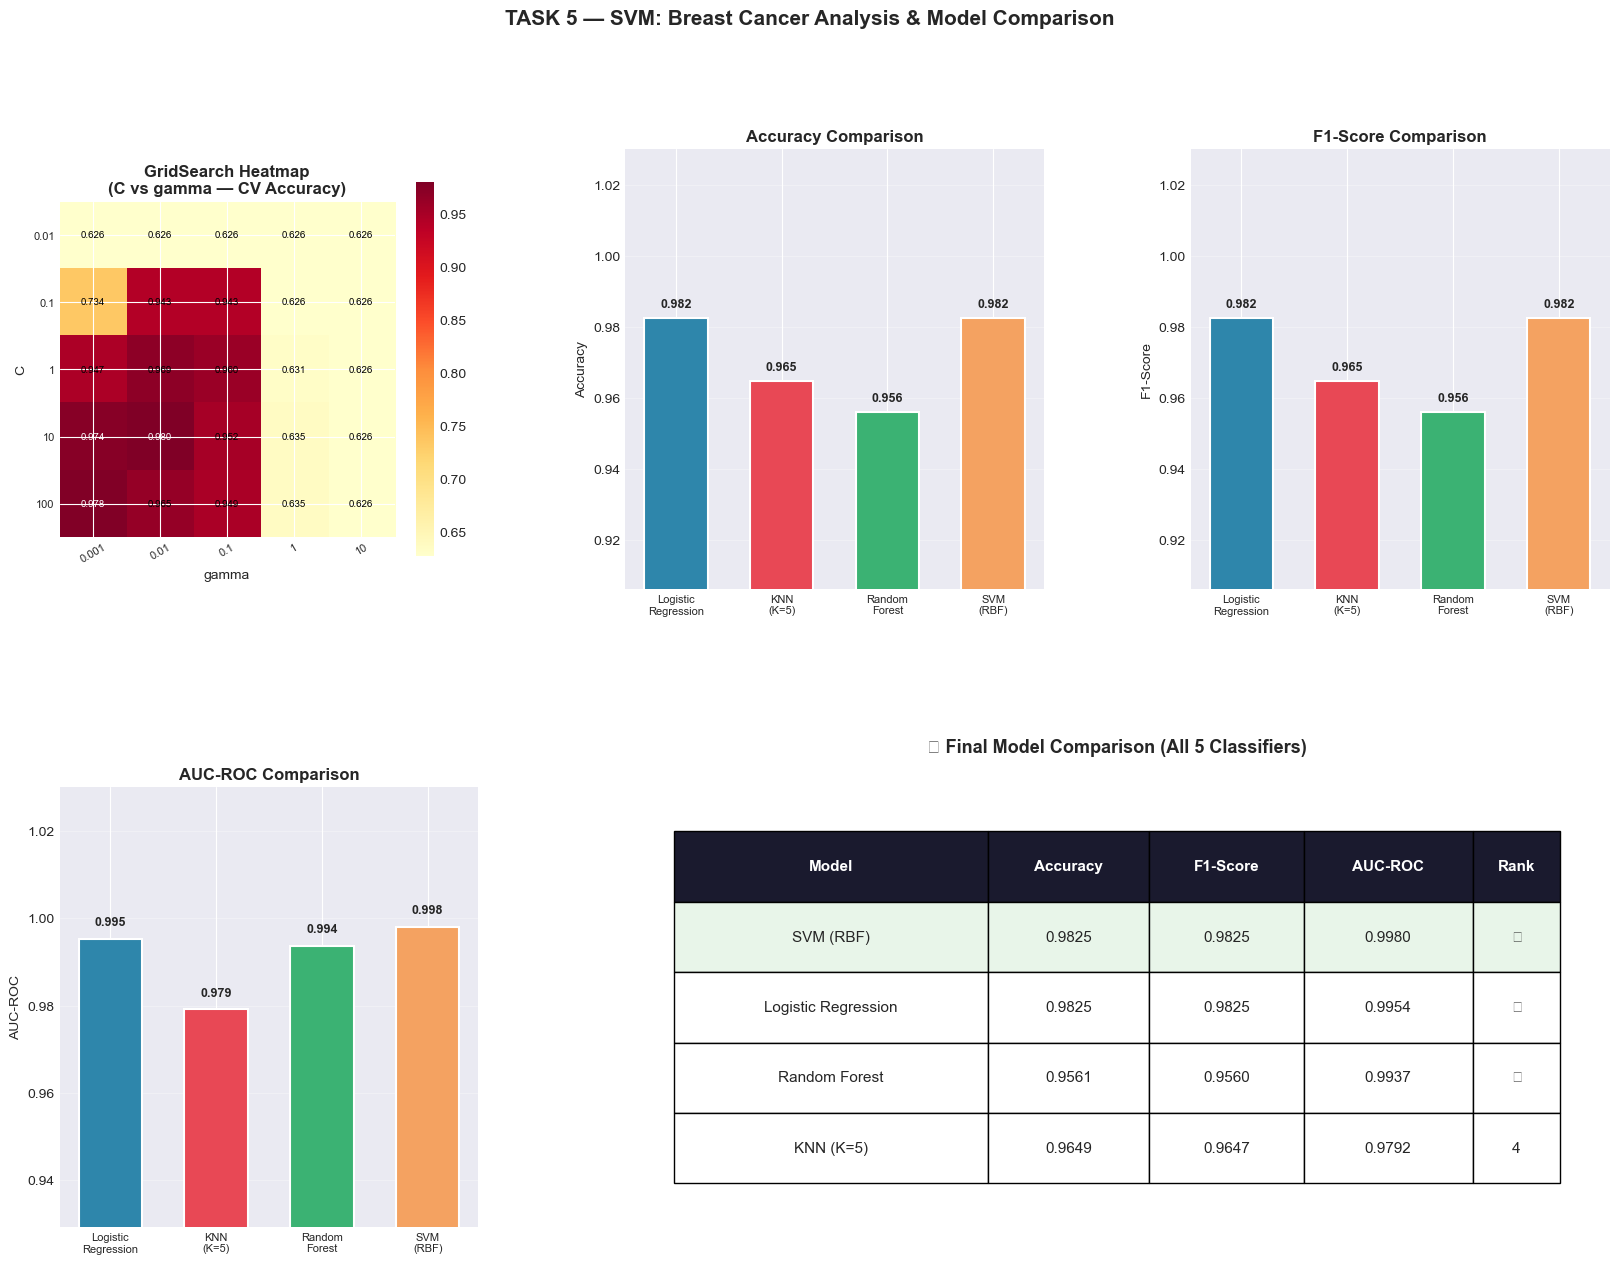


✅ TASK 5 COMPLETE — SVM Kernel Comparison!


In [1]:
# ============================================================
# TASK 5: SVM KERNEL COMPARISON LAB
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_moons, make_circles, load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = ['#2E86AB','#E84855','#3BB273','#F4A261','#8338EC']

# ── Helper: Plot Decision Boundary ───────────────────────────
def plot_decision_boundary(model, X, y, ax, title, colors=None):
    if colors is None:
        colors = [COLORS[0], COLORS[1]]
    xmn, xmx = X[:,0].min()-0.5, X[:,0].max()+0.5
    ymn, ymx = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy   = np.meshgrid(np.linspace(xmn, xmx, 200),
                             np.linspace(ymn, ymx, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.contour(xx,  yy, Z, colors='black', linewidths=1.2)
    for cls, col in zip([0,1], colors):
        msk = y == cls
        ax.scatter(X[msk,0], X[msk,1], c=col, s=25,
                   alpha=0.7, edgecolors='white', lw=0.3)

    # Mark support vectors if available
    if hasattr(model, 'support_vectors_'):
        ax.scatter(model.support_vectors_[:,0],
                   model.support_vectors_[:,1],
                   s=80, facecolors='none',
                   edgecolors='gold', lw=1.5,
                   label='Support Vectors')
        ax.legend(fontsize=7)

    acc = accuracy_score(y, model.predict(X))
    ax.set_title(f'{title}\n(Acc={acc:.3f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

# ============================================================
# SYNTHETIC DATA: MAKE_MOONS & MAKE_CIRCLES
# ============================================================

print("=" * 65)
print("  SVM KERNEL COMPARISON — SYNTHETIC DATASETS")
print("=" * 65)

moons_X, moons_y   = make_moons(n_samples=300,  noise=0.2, random_state=42)
circles_X, circles_y = make_circles(n_samples=300, noise=0.15,
                                      factor=0.5, random_state=42)

# Scale
sc = StandardScaler()
moons_X_sc   = sc.fit_transform(moons_X)
circles_X_sc = sc.fit_transform(circles_X)

# Kernels to test
kernels_configs = [
    ('linear',    {},            'Linear Kernel'),
    ('poly',      {'degree':2},  'Polynomial (d=2)'),
    ('poly',      {'degree':3},  'Polynomial (d=3)'),
    ('rbf',       {},            'RBF Kernel'),
]

fig1 = plt.figure(figsize=(20, 10))
fig1.suptitle('TASK 5 — SVM Kernels: make_moons & make_circles',
              fontsize=15, fontweight='bold')
gs1 = gridspec.GridSpec(2, 4, hspace=0.45, wspace=0.35)

print(f"\n{'Kernel':<20} {'Moons Acc':>12} {'Circles Acc':>12}")
print("-" * 46)

for col, (kernel, params, name) in enumerate(kernels_configs):
    # Moons
    svm_m = SVC(kernel=kernel, C=1.0, **params, random_state=42)
    svm_m.fit(moons_X_sc, moons_y)
    ax_m  = fig1.add_subplot(gs1[0, col])
    plot_decision_boundary(svm_m, moons_X_sc, moons_y, ax_m, name)
    ax_m.set_xlabel('Feature 1'); ax_m.set_ylabel('Feature 2')

    # Circles
    svm_c = SVC(kernel=kernel, C=1.0, **params, random_state=42)
    svm_c.fit(circles_X_sc, circles_y)
    ax_c  = fig1.add_subplot(gs1[1, col])
    plot_decision_boundary(svm_c, circles_X_sc, circles_y, ax_c, name)
    ax_c.set_xlabel('Feature 1'); ax_c.set_ylabel('Feature 2')

    print(f"{name:<20} "
          f"{accuracy_score(moons_y, svm_m.predict(moons_X_sc)):>12.4f} "
          f"{accuracy_score(circles_y, svm_c.predict(circles_X_sc)):>12.4f}")

# Row labels
fig1.text(0.01, 0.72, 'make_moons', va='center',
          rotation='vertical', fontsize=12, fontweight='bold', color=COLORS[0])
fig1.text(0.01, 0.27, 'make_circles', va='center',
          rotation='vertical', fontsize=12, fontweight='bold', color=COLORS[1])

plt.show()

# ============================================================
# BREAST CANCER — RBF SVM + GRIDSEARCHCV
# ============================================================

print("\n" + "=" * 65)
print("  BREAST CANCER — RBF SVM + GridSearchCV")
print("=" * 65)

bc      = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
scaler_bc   = StandardScaler()
X_bc_sc     = scaler_bc.fit_transform(X_bc)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_bc_sc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

# GridSearch: C and gamma
param_grid_svm = {
    'C'    : [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10],
}

gs_svm = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1
)
gs_svm.fit(X_tr, y_tr)

print(f"Best C     : {gs_svm.best_params_['C']}")
print(f"Best gamma : {gs_svm.best_params_['gamma']}")
print(f"Best CV Acc: {gs_svm.best_score_:.4f}")

svm_best = gs_svm.best_estimator_
svm_pred = svm_best.predict(X_te)
svm_prob = svm_best.predict_proba(X_te)[:, 1]
svm_acc  = accuracy_score(y_te, svm_pred)
svm_f1   = f1_score(y_te, svm_pred, average='weighted')
svm_auc  = roc_auc_score(y_te, svm_prob)

print(f"\nSVM Test Accuracy : {svm_acc:.4f}")
print(f"SVM F1-Score      : {svm_f1:.4f}")
print(f"SVM AUC-ROC       : {svm_auc:.4f}")

# GridSearch Heatmap
scores_matrix = gs_svm.cv_results_['mean_test_score'].reshape(5, 5)

fig2 = plt.figure(figsize=(20, 14))
fig2.suptitle('TASK 5 — SVM: Breast Cancer Analysis & Model Comparison',
              fontsize=15, fontweight='bold')
gs2_ = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

# Plot 1: GridSearch Heatmap
ax1 = fig2.add_subplot(gs2_[0, 0])
im = ax1.imshow(scores_matrix, interpolation='nearest', cmap='YlOrRd',
                vmin=scores_matrix.min(), vmax=scores_matrix.max())
plt.colorbar(im, ax=ax1, shrink=0.85)
C_vals     = [0.01, 0.1, 1, 10, 100]
gamma_vals = [0.001, 0.01, 0.1, 1, 10]
ax1.set_xticks(range(5))
ax1.set_xticklabels([str(g) for g in gamma_vals], fontsize=8, rotation=30)
ax1.set_yticks(range(5))
ax1.set_yticklabels([str(c) for c in C_vals], fontsize=8)
ax1.set_xlabel('gamma'); ax1.set_ylabel('C')
ax1.set_title('GridSearch Heatmap\n(C vs gamma — CV Accuracy)',
              fontweight='bold')
for i in range(5):
    for j in range(5):
        ax1.text(j, i, f'{scores_matrix[i,j]:.3f}',
                 ha='center', va='center', fontsize=7,
                 color='white' if scores_matrix[i,j] > 0.97 else 'black')

# ── ALL 5 CLASSIFIERS COMPARISON ────────────────────────────
print("\n" + "=" * 65)
print("  COMPARING ALL 5 CLASSIFIERS")
print("=" * 65)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (K=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', C=gs_svm.best_params_['C'],
                      gamma=gs_svm.best_params_['gamma'],
                      probability=True, random_state=42),
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    prob = clf.predict_proba(X_te)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_te, pred),
        'F1-Score': f1_score(y_te, pred, average='weighted'),
        'AUC-ROC':  roc_auc_score(y_te, prob),
    }
    print(f"{name:<22}: Acc={results[name]['Accuracy']:.4f}  "
          f"F1={results[name]['F1-Score']:.4f}  "
          f"AUC={results[name]['AUC-ROC']:.4f}")

# Plot 2, 3, 4: Metrics Comparison Bar Charts
for m_idx, metric in enumerate(['Accuracy', 'F1-Score', 'AUC-ROC']):
    ax = fig2.add_subplot(gs2_[0, m_idx+1] if m_idx < 2
                           else gs2_[1, 0])
    names  = list(results.keys())
    vals   = [results[n][metric] for n in names]
    colors = [COLORS[i % len(COLORS)] for i in range(len(names))]
    bars   = ax.bar(range(len(names)), vals,
                    color=colors, edgecolor='white', lw=1.5, width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.003,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace(' ','\n') for n in names], fontsize=8)
    ax.set_ylim(min(vals)-0.05, 1.03)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel(metric); ax.grid(True, alpha=0.3, axis='y')

# Plot 5: Radar / Final Summary Table
ax5 = fig2.add_subplot(gs2_[1, 1:])
ax5.axis('off')
table_header = ['Model', 'Accuracy', 'F1-Score', 'AUC-ROC', 'Rank']
sorted_names = sorted(results.keys(),
                      key=lambda n: results[n]['AUC-ROC'], reverse=True)
table_rows = []
for rank, name in enumerate(sorted_names, 1):
    r = results[name]
    table_rows.append([
        name, f"{r['Accuracy']:.4f}",
        f"{r['F1-Score']:.4f}",
        f"{r['AUC-ROC']:.4f}",
        f"{'🥇' if rank==1 else '🥈' if rank==2 else '🥉' if rank==3 else str(rank)}"
    ])

tbl = ax5.table(cellText=table_rows, colLabels=table_header,
                cellLoc='center', loc='center',
                bbox=[0.05, 0.1, 0.9, 0.8])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
tbl.auto_set_column_width(col=list(range(5)))

for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a1a2e')
        cell.set_text_props(color='white', fontweight='bold')
    elif r == 1:   # Best model
        cell.set_facecolor('#E8F5E9')
cell.set_text_props(fontweight='bold')
ax5.set_title('🏆 Final Model Comparison (All 5 Classifiers)',
              fontweight='bold', fontsize=13, pad=25)

plt.show()
print("\n✅ TASK 5 COMPLETE — SVM Kernel Comparison!")